# **Lab 4 -  Correlation Datasets and Dataloaders**

# **Computer Vision (10224)**

  
## **Goals**

* Learn how to create a bounding box around the important area in the image
* Learn to write a dataset object for various datasets and for various tasks (classification, segmentation, detection etc.)
* combine the default pytorch dataloader and dataset ( will be used in future labs to actually train a model)
* Learn to add augmentation using common augmentation library.



## **Further Reading / Reference**

1. [documentation of pytorch dataset](https://pytorch.org/tutorials/recipes/recipes/custom_dataset_transforms_loader.html#developing-custom-pytorch-dataloaders), especially section 1.2: "Create a dataset class"  
2. [documentation of albumentations classification task augmentations](https://albumentations.ai/docs/getting_started/image_augmentation/)
3. [migrating_from_torchvision_to_albumentations/](https://albumentations.ai/docs/examples/migrating_from_torchvision_to_albumentations)


## **Lab Session**

1. correlation
2. torch default datasets (for MNIST)
3. visualizing a sample
4. augmenting a sample using albumentations
5. Show result typical results (up to 30 images)
6. writing a custom dataset for mnist and adding the albumentations augmentation to it


## LAB Session

## Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
%matplotlib inline
from PIL import Image
import albumentations  as A
import cv2


In [2]:
# assintant function to get the basic info about the image
def get_image_basic_info(img, sep =', '):
    return f"{type(img) = }" + sep + f"{img.max() = :.2f}"+ sep + f"{img.min() = :.2f}" + sep + f"{img.mean()= :.2f}"


## Normalized Cross Correlation (NCC)

Detect the number "10" on Messi jersey in an image using template matching using normalized cross-correlation (NCC)

$NCC[m, n] = \frac{\sum_{i,j}(t[i,j]-\bar{t})(p[m+i, n+j]-\bar{p}_{mn})}{\sqrt{\sum_{i,j}(t[i,j]-\bar{t})^{2} \cdot \sum_{i,j}(p[m+i, n+j]-\bar{p}_{mn})^{2}}}$

Where $\bar{p}_{mn}$ is the mean of the image patch, and $\bar{t}$ is the mean of the template.

Load the image of Messi with his jersey number clearly visible.

In [76]:
# If you are using colab
!wget http://www.turtleluck.com/wp-content/uploads/2014/06/Lionel-Messi.jpg -O messi.jpg

--2025-04-09 07:34:10--  http://www.turtleluck.com/wp-content/uploads/2014/06/Lionel-Messi.jpg
Resolving www.turtleluck.com (www.turtleluck.com)... 185.146.22.247
Connecting to www.turtleluck.com (www.turtleluck.com)|185.146.22.247|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37353 (36K) [image/jpeg]
Saving to: ‘messi.jpg’

messi.jpg           100%[===================>]  36.48K  --.-KB/s    in 0.09s   

2025-04-09 07:34:11 (425 KB/s) - ‘messi.jpg’ saved [37353/37353]



In [ ]:
# If you are using local machine
import sys
path = '' # TODO - add the image path
sys.path.append(path)

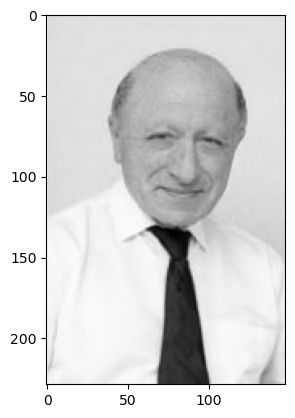

In [3]:
img = cv2.imread('Reuven.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(img, cmap='gray')
plt.show()

### Create label (patch) image
In this part we want to create the template image.
Crop Messi image around his number, and plot the template and the full image.

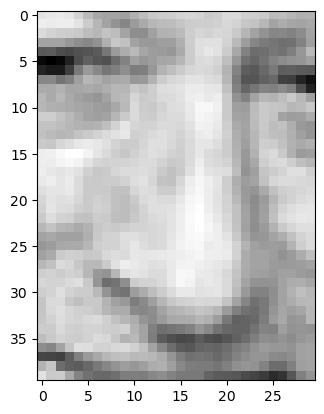

In [18]:
# Crop the template (number "10")
#       x1, y1, x2, y2
# Your code goes here# Extract template of size 15x30 from coordinates (x=70 to 84, y=70 to 99)
template = img[70:110, 70:100]  # y-range first, then x-range

plt.imshow(template, cmap='gray')
plt.show()


### Implement the <code>ncc</code> function.

In [98]:
def ncc(img, image_patch):
    """
    Compute Normalized Cross-Correlation (NCC) between a template and an image.

    Parameters:
    - img: 2D array (grayscale image) in which the NCC will be computed.
    - image_patch: 2D array (template) to match within the image.

    Returns:
    - result: 2D array containing the NCC score at each position.
    """
    # Your code goes here

    return result


In [99]:
# result = ncc(img, template)

Find the best match location, draw rectangle around the best match patch and plot the results.

**Note:** You can use build-in <code>cv2.rectangle</code> function.

Best match top-left corner (y, x): (70, 70)


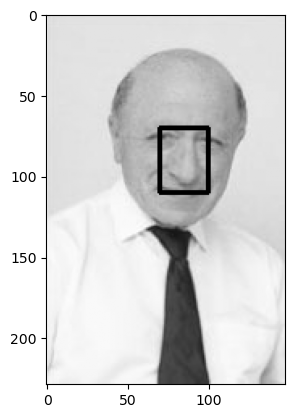

In [20]:
# Get the best match location
th, tw = template.shape  # height and width of the template

# Perform Normalized Cross-Correlation (NCC)
result = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)
max_idx = np.unravel_index(np.argmax(result), result.shape) # Converts a flat array of flat indices into a tuple of coordinate arrays.

print("Best match top-left corner (y, x):", max_idx)

# Get rectangle corners
top_left = (max_idx[1], max_idx[0])  # x, y
bottom_right = (top_left[0] + tw, top_left[1] + th)

# Draw rectangle on original image
cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)

# Draw rectangle
# Your code goes here

plt.imshow(img, cmap='gray')
plt.show()


## Torchvision common datasets vs custom datasets
Many Datasets has existing Dataset classes already implemented in torchvision.dataset:
https://pytorch.org/vision/main/datasets.html <br><br>
 ([MNIST is one of them](https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST)) <br>
 * We will start by using torchvision MNIST implementation and than we will implement it our self (for methodological reasons).

 * In a Future Lab we will use the output of your homework ( 3 digits MNIST to train a model this custom dataset).

 * It's important to know to write a Dataset Class for your own datasets so you can train models on custom datasets.  

### Downloading the data
we are downloading the dataset with the torchvision exisiting MNIST  Dataset class,
alternatively we could download the data from the internet for example using this commnented out commands:   
<code>
  !wget www.di.ens.fr/~lelarge/MNIST.tar.gz <br>
  !tar -zxvf MNIST.tar.gz
</code>

In [21]:
# We are initializng the dataset object using torchvision
# exisiting implementation and  also downloading the data (see download = True)
train_set = torchvision.datasets.MNIST(root='', train=True, download=True)
test_set = torchvision.datasets.MNIST(root='', train=True, download=True)

# train_set = torchvision.datasets.MNIST(root='', train=True, download=False)
# test_set = torchvision.datasets.MNIST(root='', train=True, download=False)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:58<00:00, 169kB/s] 


Extracting MNIST\raw\train-images-idx3-ubyte.gz to MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 187kB/s]


Extracting MNIST\raw\train-labels-idx1-ubyte.gz to MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:15<00:00, 108kB/s] 


Extracting MNIST\raw\t10k-images-idx3-ubyte.gz to MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.46MB/s]


Extracting MNIST\raw\t10k-labels-idx1-ubyte.gz to MNIST\raw



In [22]:
num_classes = len(train_set.classes)
print(f"{train_set.targets[:20] = },\n{len(train_set.classes) = }")

train_set.targets[:20] = tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9]),
len(train_set.classes) = 10


### Visualazing samples


In [23]:
# get a random sample from the train dataset
def get_single_sample(dataset_object: Dataset, sample_index = None):
  if type(sample_index) == type(None):
      # np.random.seed(1234) # for sanity check
      sample_index = np.random.randint(0, len(dataset_object))
  if not isinstance(sample_index, int):
    raise TypeError(f'expected type of sample index (if provided )is int, yet {type(sample_index) = }')
  img2augment, label = dataset_object[sample_index][0], dataset_object[sample_index][1]
  return img2augment, label, sample_index


sample_index =0, type(img) = <class 'PIL.Image.Image'>,  label = 5, type(label) = <class 'int'>


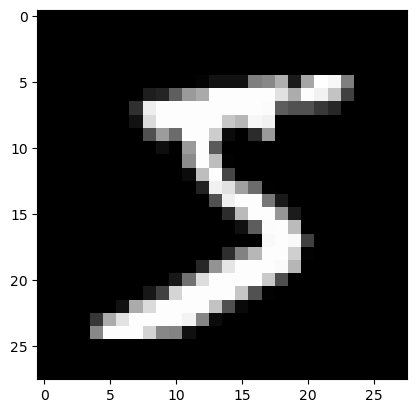

sample_index =1500, type(img) = <class 'PIL.Image.Image'>,  label = 9, type(label) = <class 'int'>


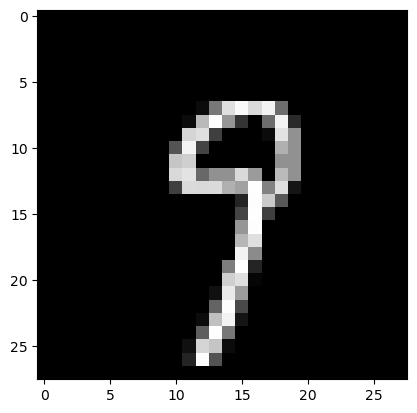

In [25]:
img, label, sample_index = get_single_sample(train_set, sample_index=0)
print(f"{sample_index =}, {type(img) = },  {label = }, {type(label) = }")
# Your Turn : write a code to plot the sample image
plt.imshow(img, cmap='gray')
plt.show()
img, label, sample_index = get_single_sample(train_set)
print(f"{sample_index =}, {type(img) = },  {label = }, {type(label) = }")
# Your Turn : write a code to plot the sample image
plt.imshow(img, cmap='gray')


## converting PIL image to np array

In [26]:
def pil2np(img):
  if isinstance(img, Image.Image):
    return np.array(img)
  return img

class PIL2Numpy(object):

    def apply(self, img):
        return pil2np(img)

    def __call__(self, img):
        return self.apply(img)


sample_index =1500, type(img) = <class 'PIL.Image.Image'>,  label = 9, type(label) = <class 'int'>

sample_index =1500, type(img_nmp) = <class 'numpy.ndarray'>,  label = 9, type(label) = <class 'int'>



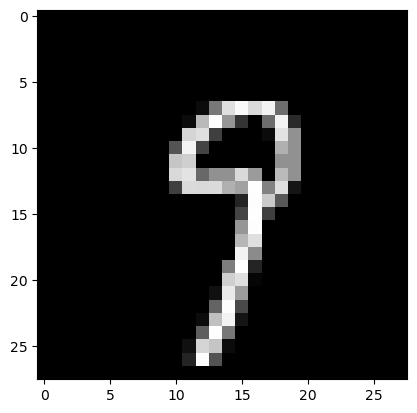

In [28]:
# converting to PIL Image 2 numpy

print(f"{sample_index =}, {type(img) = },  {label = }, {type(label) = }\n")
# your turn convert a PIL image to numpy and  plot it
img_nmp = pil2np(img)
print(f"{sample_index =}, {type(img_nmp) = },  {label = }, {type(label) = }\n")
plt.imshow(img_nmp, cmap='gray')

## Augmenting sample

sample_index =24776, type(img) = <class 'PIL.Image.Image'>,  label = 0, type(label) = <class 'int'>
sample_index =24776, type(augmented_img) = <class 'numpy.ndarray'>,  label = 0, type(label) = <class 'int'>


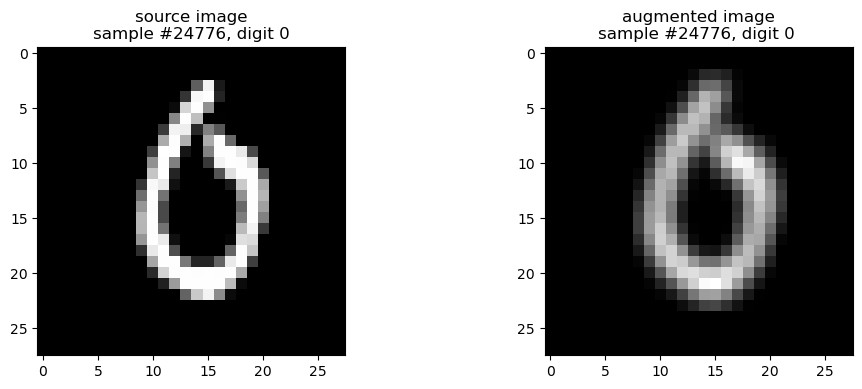

sample_index =42089, type(img) = <class 'PIL.Image.Image'>,  label = 6, type(label) = <class 'int'>
sample_index =42089, type(augmented_img) = <class 'numpy.ndarray'>,  label = 6, type(label) = <class 'int'>


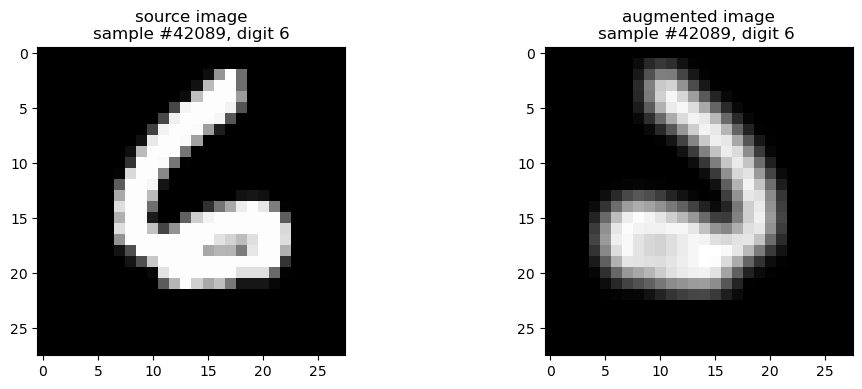

sample_index =41926, type(img) = <class 'PIL.Image.Image'>,  label = 5, type(label) = <class 'int'>
sample_index =41926, type(augmented_img) = <class 'numpy.ndarray'>,  label = 5, type(label) = <class 'int'>


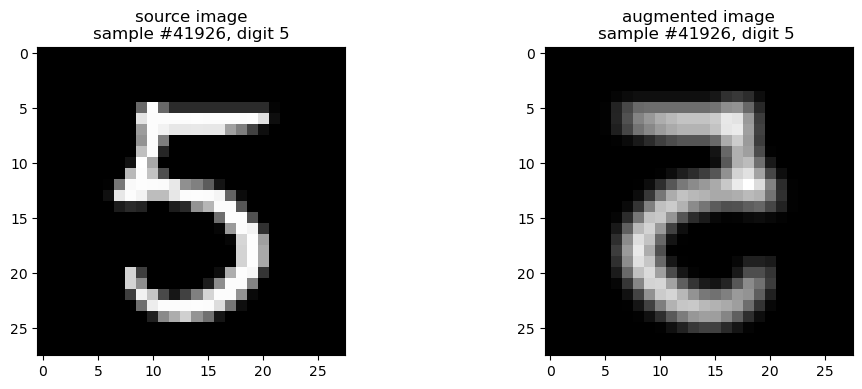

In [29]:
# define augmentation pipeline
mnist_tansforms = A.Compose([
    A.Blur(blur_limit=5),
    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=45)],
        p=0.5)
    ])
for _ in range(3):
  img, label, sample_index = get_single_sample(train_set)
  img_np = pil2np(img)

  print(f"{sample_index =}, {type(img) = },  {label = }, {type(label) = }")
  augmented_img = mnist_tansforms(image=img_np)['image']
  print(f"{sample_index =}, {type(augmented_img) = },  {label = }, {type(label) = }")
  plt.figure(figsize=(12,4))
  plt.subplot(121)
  plt.imshow(img, 'gray')
  plt.title(f"source image\nsample #{sample_index}, digit {label}")
  plt.subplot(122)
  plt.imshow(augmented_img, 'gray')
  plt.title(f'augmented image\nsample #{sample_index}, digit {label} ')
  plt.show()



## Your turn augment 3 samples for each digit
chose reasonable augmentations, (rotation by 180 ) are not reasonable because it will mix 6 with 9.


sample_index =49996, type(img) = <class 'PIL.Image.Image'>,  label = 0, type(label) = <class 'int'>
sample_index =49996, type(augmented_img) = <class 'numpy.ndarray'>,  label = 0, type(label) = <class 'int'>


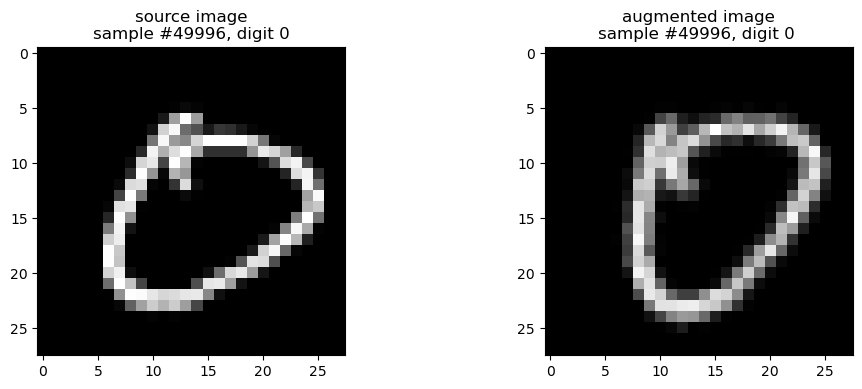

sample_index =36753, type(img) = <class 'PIL.Image.Image'>,  label = 2, type(label) = <class 'int'>
sample_index =36753, type(augmented_img) = <class 'numpy.ndarray'>,  label = 2, type(label) = <class 'int'>


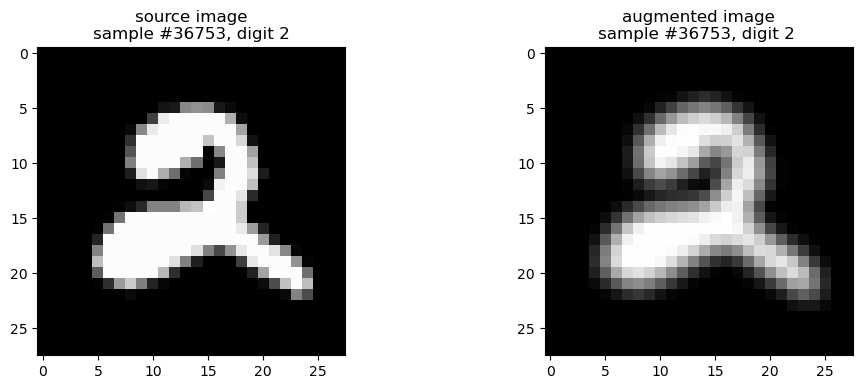

sample_index =21686, type(img) = <class 'PIL.Image.Image'>,  label = 9, type(label) = <class 'int'>
sample_index =21686, type(augmented_img) = <class 'numpy.ndarray'>,  label = 9, type(label) = <class 'int'>


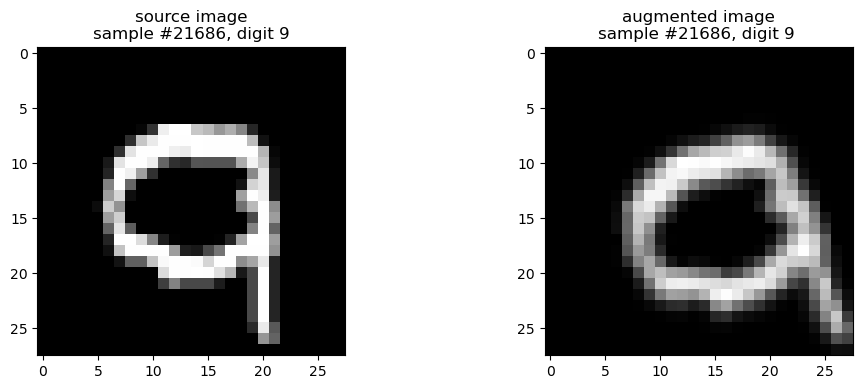

In [31]:
# Your turn augment 3 samples for each digint
# WRITE YOUR CODE IN THIS CELL
mnist_transforms2 = A.Compose([
    A.GaussianBlur(blur_limit=(1, 2), p=0.3),  # Light blur, probabilistic
    A.Rotate(limit=35, p=0.43),                # Small angle rotation
    A.Affine(scale=(0.9, 1.1), translate_percent=0.1, p=0.5),  # Random shift/zoom
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),  # Mimics handwriting variation
])

for _ in range(3):
  img, label, sample_index = get_single_sample(train_set)
  img_np = pil2np(img)

  print(f"{sample_index =}, {type(img) = },  {label = }, {type(label) = }")
  augmented_img = mnist_transforms2(image=img_np)['image']
  print(f"{sample_index =}, {type(augmented_img) = },  {label = }, {type(label) = }")
  plt.figure(figsize=(12,4))
  plt.subplot(121)
  plt.imshow(img, 'gray')
  plt.title(f"source image\nsample #{sample_index}, digit {label}")
  plt.subplot(122)
  plt.imshow(augmented_img, 'gray')
  plt.title(f'augmented image\nsample #{sample_index}, digit {label} ')
  plt.show()


## Your Turn Implementing custom Dataset

In [ ]:
class MyMNISTDataset(Dataset): # inherits from torch build in Dataset class
  #   creates your dataset

  def __init__(self, train_set, transforms=None):
    super(MyMNISTDataset, self).__init__()
    # data loading and splitting to data and labels
    self.xs = train_set.data
    self.ys = train_set.targets
    self.transforms = transforms

  def __getitem__(self, idx):  # allow indexing
    #   dataset[idx]

    x = self.xs[idx]# your code here
    y = self.ys[idx]# your code here

    ###################### Optional pre_processing ########################
    # x = apply preprocessing for example converting PIL2Numpy if needed
    # you can let the user specify the pre-processing callable
    # in the init implementation
    ######################################################################

    # Apply augmentation (if provided)

    if self.transforms:
      # Your Code Here
      augmented = self.transforms(image=x)
      x = augmented['image']


    ###################### Optinal post_processing ########################
    # post-processing (for example converting image and labels to torch.tensor)
    # you can let the user specify the pre-processing callable
    # in the init implementation
    ######################################################################

    return x, y

  def __len__(self):
    #   length of the dataset
    ds_len = len(self.xs)# Your code here
    return ds_len

In [ ]:
mnist_tansforms = A.Compose([
    A.Blur(blur_limit=5),
    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=45)],
        p=0.5)
    ])

mnist_dataset_train = MyMNISTDataset(train_set,
                                   transforms=mnist_tansforms)
mnist_dataset_test = MyMNISTDataset(test_set,
                                  #  transforms=mnist_tansforms
                                   )

## Torch Dataloader: iterate over dataset
we will use the dataloader in the future when we will be training models

In [ ]:
single_sample = mnist_dataset_train[0]
print(f"{type(single_sample[0]) = }")
print(f"{type(single_sample[1]) = }")


type(single_sample[0]) = <class 'numpy.ndarray'>
type(single_sample[1]) = <class 'int'>


In [ ]:
len(mnist_dataset_train)

In [ ]:
batch_size = 32
mnist_train_dataloader = DataLoader(dataset=mnist_dataset_train, batch_size=batch_size, shuffle=True)
mnist_test_dataloader = DataLoader(dataset=mnist_dataset_test, batch_size=batch_size, shuffle=False)

## Visualizing the image and labels with the dataloader
In the future we will be using the dataloader for training and not for visualization


----------


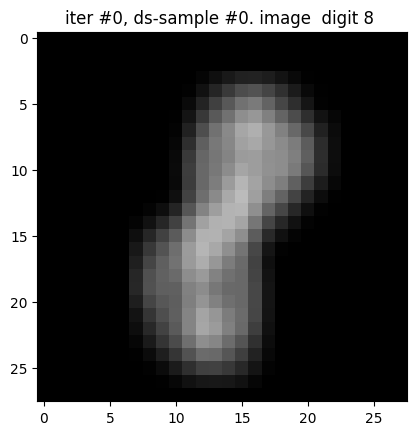

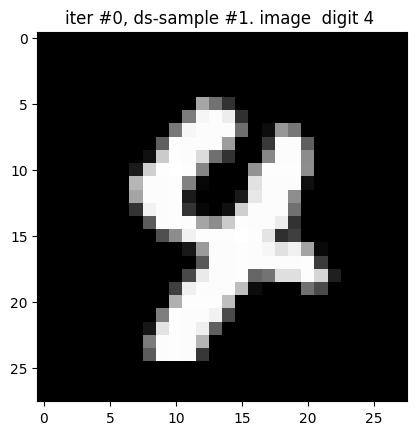

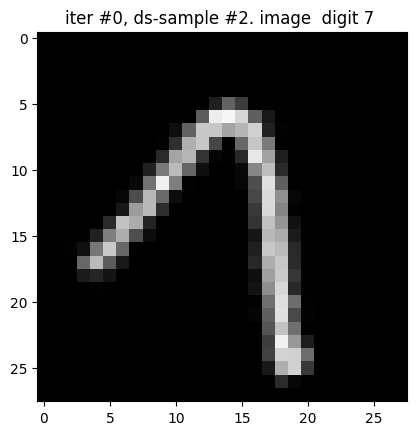

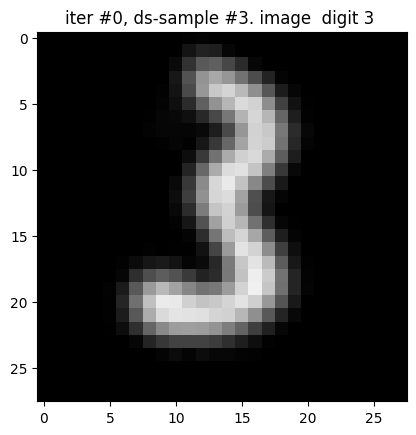


----------


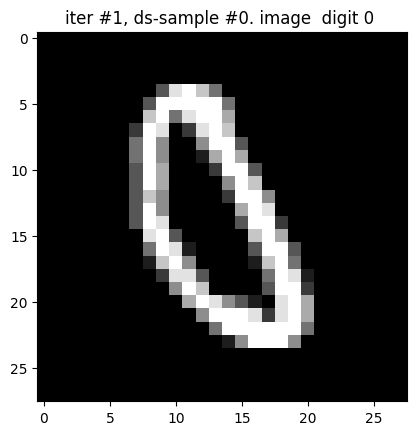

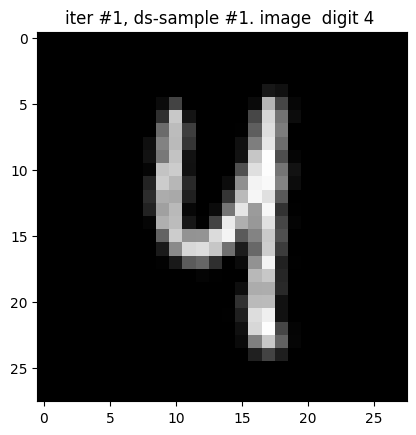

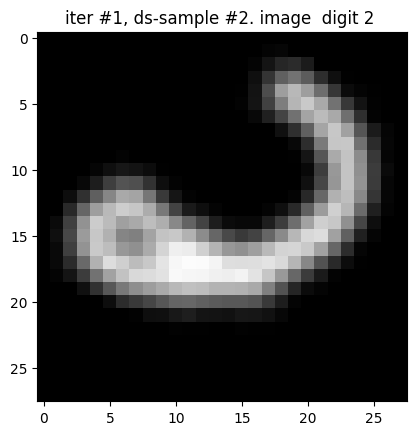

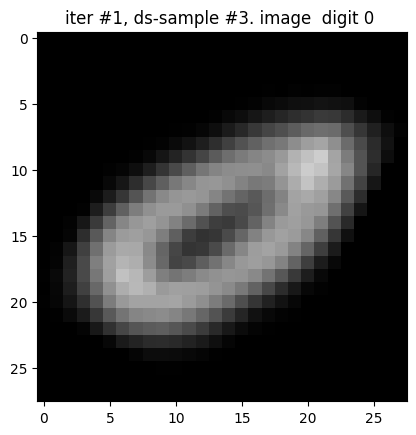


----------


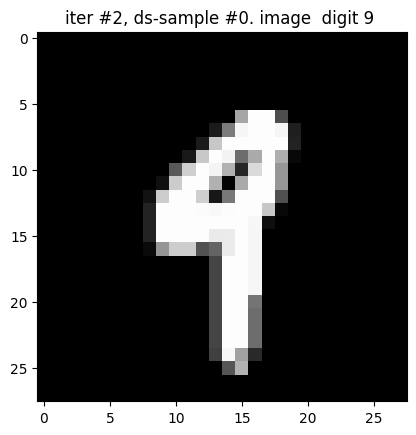

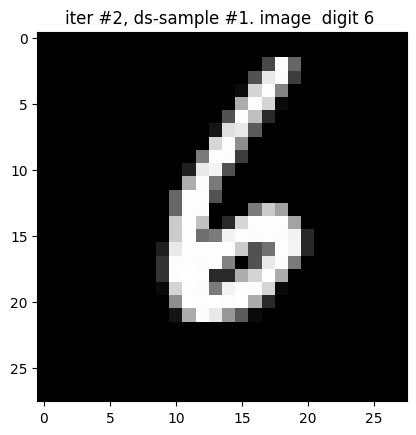

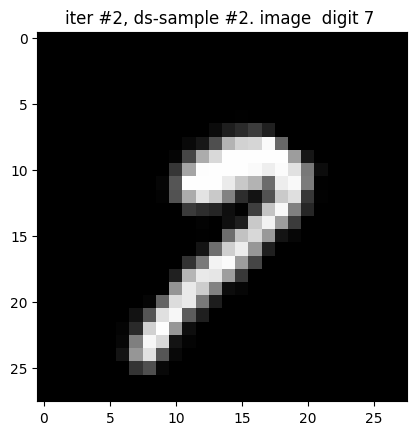

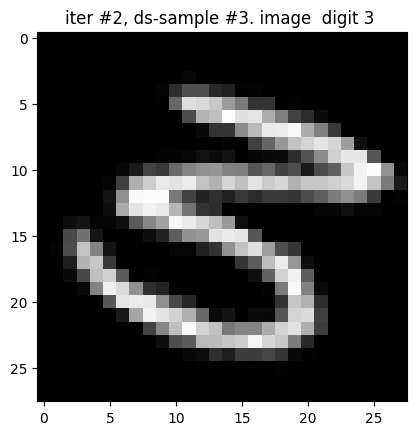


----------


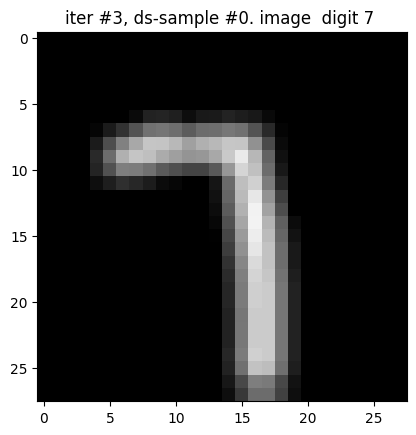

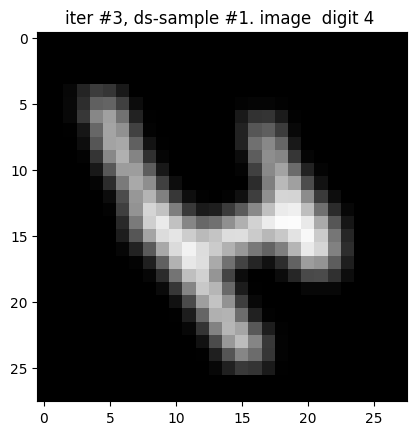

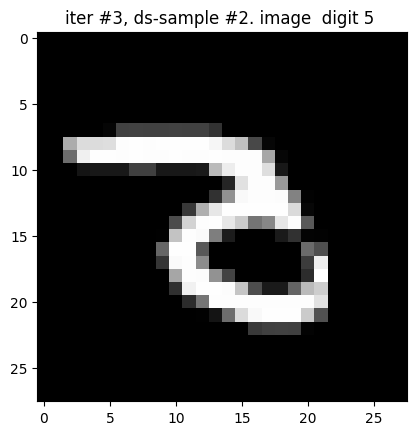

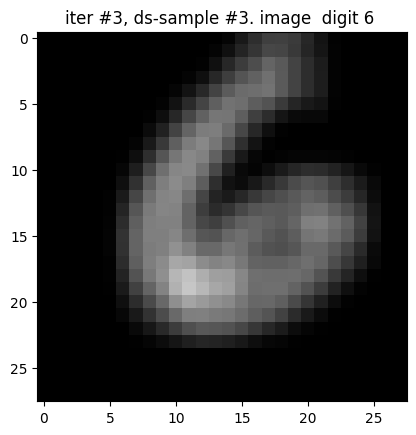

In [ ]:
for i, (imgs, labels) in enumerate(mnist_train_dataloader):
  print()
  print('-' * 10)
  for j, (img, label) in enumerate(zip(imgs, labels)):
    plt.imshow(img.numpy(), 'gray')
    plt.title(f'iter #{i}, ds-sample #{j}. image  digit {label.numpy()} ')
    plt.show()
    if j >=3:
      break
  if i >=3:
    break



----------


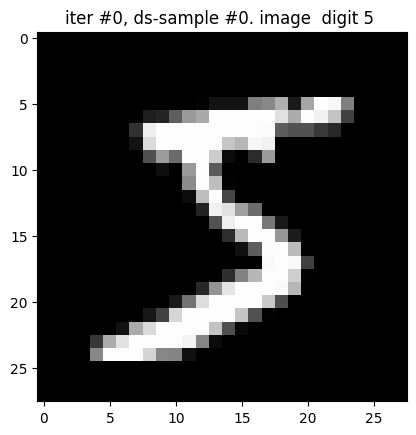

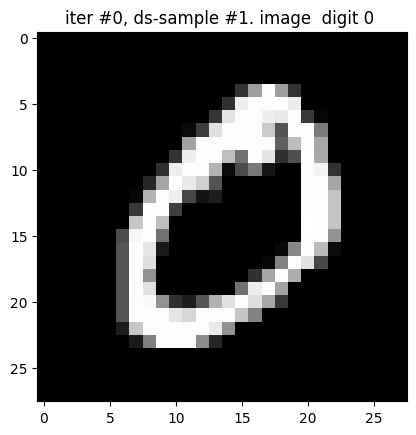

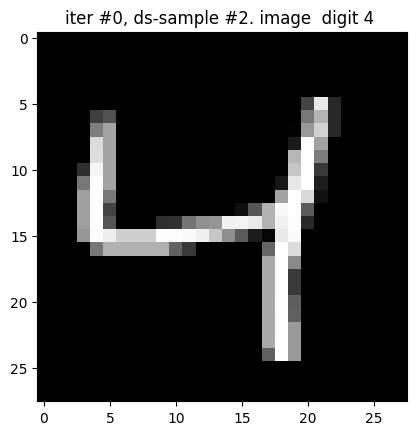

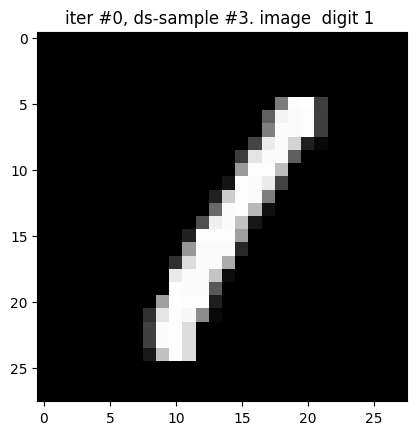


----------


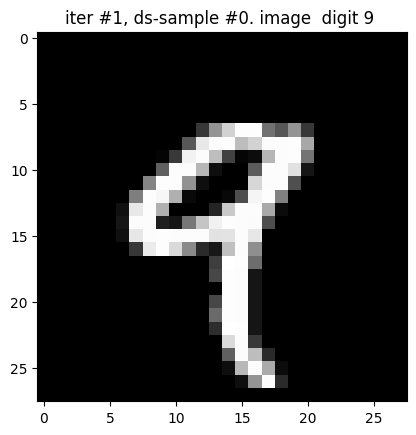

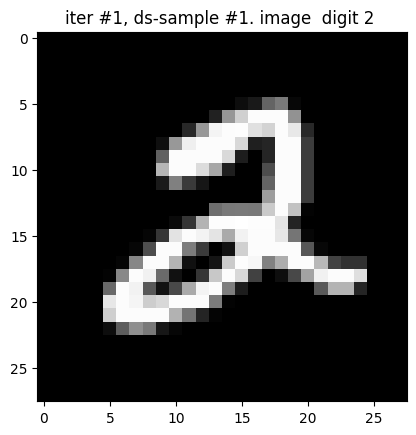

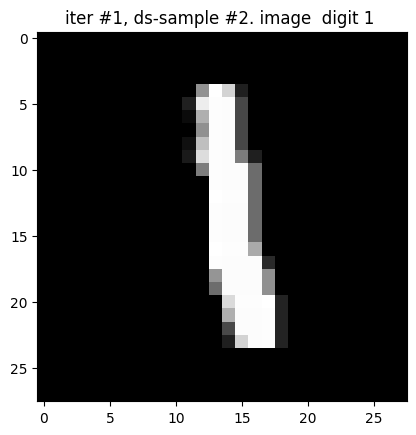

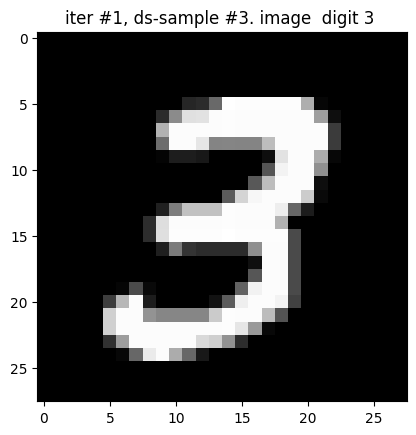


----------


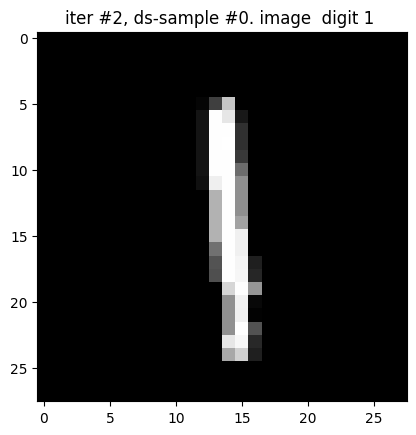

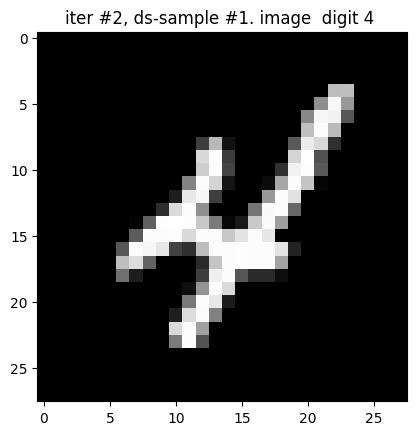

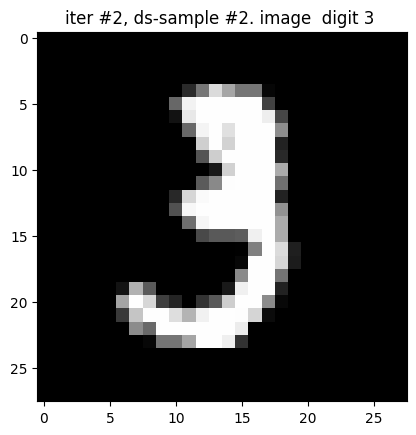

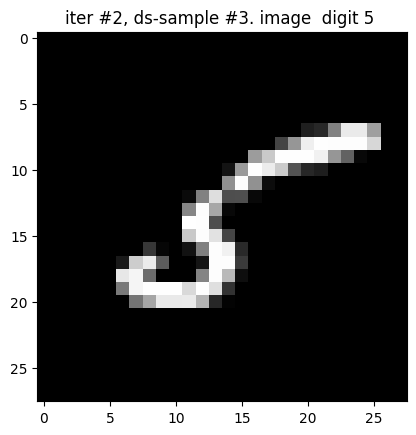


----------


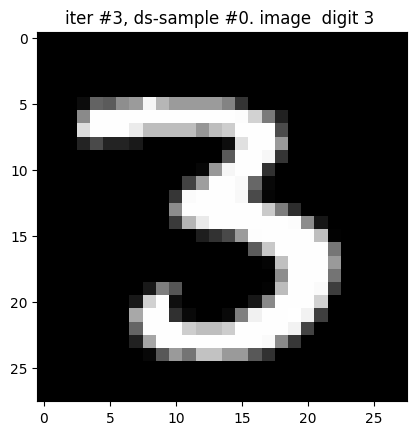

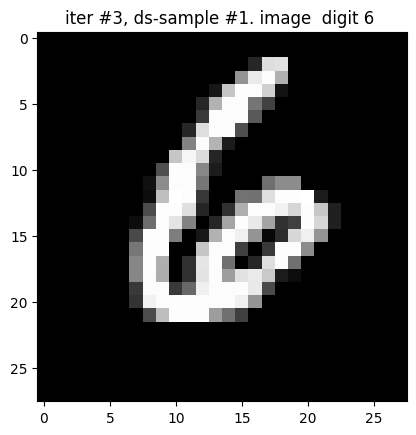

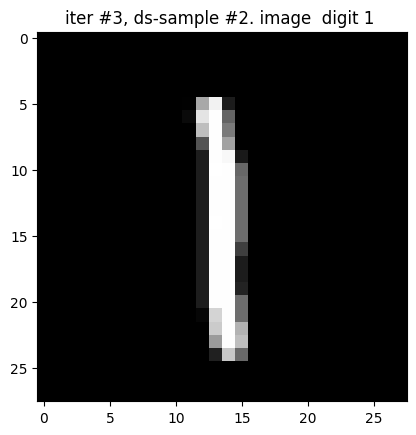

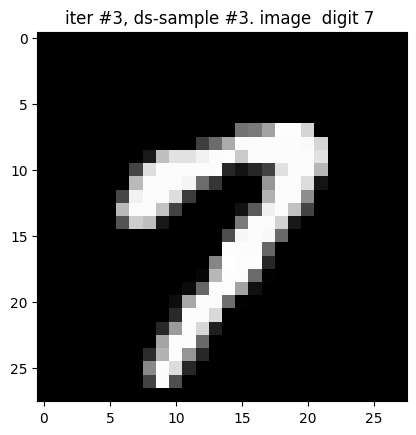

In [ ]:
for i, (imgs, labels) in enumerate(mnist_test_dataloader):
  print()
  print('-' * 10)
  for j, (img, label) in enumerate(zip(imgs, labels)):
    plt.imshow(img.numpy(), 'gray')
    plt.title(f'iter #{i}, ds-sample #{j}. image  digit {label.numpy()} ')
    plt.show()
    if j >=3:
      break
  if i >=3:
    break